## Imports

In [1]:
# Import necessary libraries for data manipulation, visualization, and file paths
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to system path for importing custom modules
import sys
sys.path.append("..")

# Import data directory from a production configuration file
from production.config import DATA_DIR

# Load the latest CSV data into a pandas DataFrame

df = pd.read_csv(DATA_DIR / "latest.csv")

In [2]:
# Display the first few rows of the DataFrame to get a quick overview of the data
df.head()

,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level
0,56,F,165.3,53.7,Dancing,41,Low,3.3,6.6,3,7128,1.5
1,56,F,165.3,53.9,Swimming,28,Low,2.9,8.1,7,7925,1.8
2,56,F,165.3,54.2,Swimming,21,Medium,2.6,6.2,7,7557,2.7
3,56,F,165.3,54.4,Weight Training,99,Medium,10.7,7.2,8,11120,2.6
4,56,F,165.3,54.7,Swimming,100,Medium,12.7,7.1,1,5406,1.5


In [3]:
# Get the unique values from the 'activity_type' column to see all distinct activity types
df['activity_type'].unique()

array(['Dancing', 'Swimming', 'Weight Training', 'HIIT', 'Running',
       'Walking', 'Tennis', 'Basketball', 'Yoga', 'Cycling'], dtype=object)

## Numerical Features Summary and Insights
Numeric features show plausible ranges across demographics, with balanced distributions and only minor anomalies already flagged during initial inspection.


In [4]:
"""
Numeric Summary
----------------

Key Takeaways:
- Most values within realistic ranges
- daily_steps include invalid negatives (min = –419)
- calories_burned unrealistically low for workout durations (median 13 kcal, expected 200–1000)

Next Steps:
1. Correct invalid daily_steps values
2. Rescale or regenerate calories_burned
3. Verify realistic relationships between key numerical features
"""

# Generates descriptive statistics for numeric features
df.describe()

,age,height_cm,weight_kg,duration_minutes,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level
count,687699.000000,687699.000000,687699.000000,687699.000000,687699.000000,687699.000000,687699.000000,687699.000000,687699.000000
mean,41.658547,168.587717,94.921938,70.011706,15.381315,7.048796,5.252385,8628.396739,2.499427
std,13.581752,9.140818,22.461819,29.147283,9.985564,0.972067,2.770029,2054.703791,0.579050
min,18.000000,145.000000,45.300000,20.000000,0.800000,4.000000,1.000000,36.000000,1.500000
25%,30.000000,161.700000,78.200000,45.000000,7.800000,6.400000,3.000000,7203.000000,2.000000
50%,42.000000,168.200000,94.600000,70.000000,13.000000,7.000000,5.000000,8607.000000,2.500000
75%,53.000000,175.300000,110.500000,95.000000,20.700000,7.700000,8.000000,10027.000000,3.000000
max,64.000000,198.500000,188.400000,120.000000,92.000000,10.000000,10.000000,17241.000000,3.500000


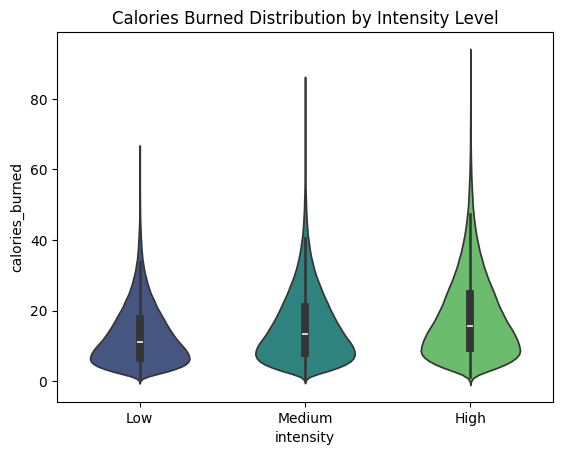

In [5]:
'''
Calories vs Intensity Level
----------------------------
- Skewed distibution for all three violin plots
- Little visible difference between Low, Medium, and High intensity categories
- The densest region is near the lower quartile: unrealistically low calories burned
- Confirms dataset is under scaled 
'''

#Violin plot with seaborn: good for understanding distribution and density
sns.violinplot(x='intensity', y='calories_burned', data=df, hue='intensity', palette='viridis',legend=False, width=0.6)
plt.title("Calories Burned Distribution by Intensity Level")
plt.show()

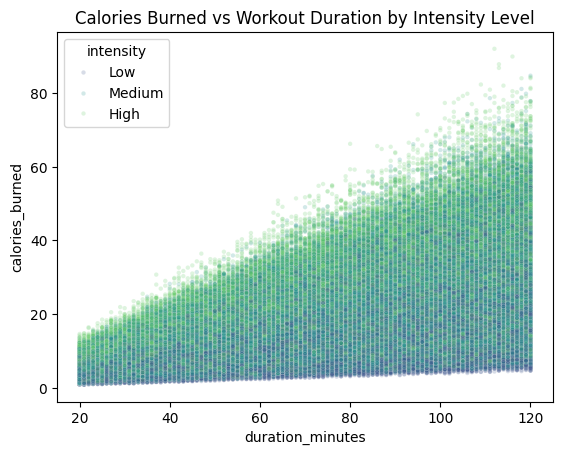

In [6]:
# Create a scatter plot to visualize the relationship between workout duration and calories burned, colored by intensity level
sns.scatterplot(x='duration_minutes', y='calories_burned', hue='intensity', data=df, alpha=0.2, s=10, palette='viridis')
plt.title("Calories Burned vs Workout Duration by Intensity Level")
plt.show()

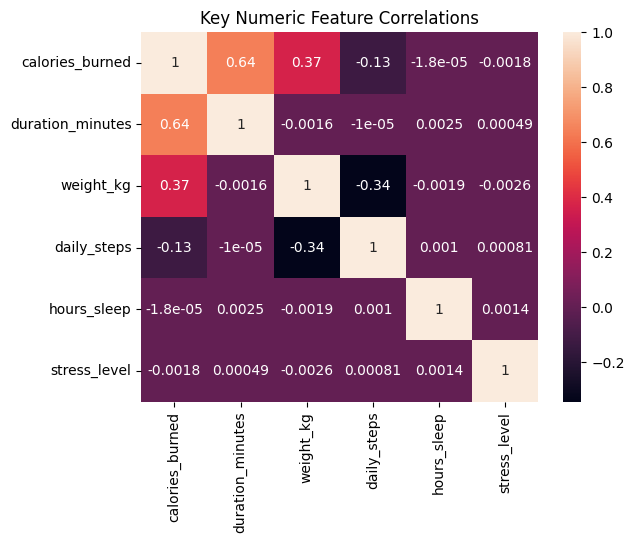

In [7]:
sns.heatmap(df[['calories_burned','duration_minutes','weight_kg','daily_steps','hours_sleep','stress_level']].corr(), annot=True)
plt.title("Key Numeric Feature Correlations")
plt.show()

## Categorical Feature Summary

In [8]:
# Converting intensity to int for visualisation
df['intensity_cat'] = df['intensity'].map({'Low': 0, 'Medium': 1, 'High': 2}).astype(int)

In [9]:
# Visualising categorical cols
cat_cols = ['gender', 'activity_type', 'intensity', 'intensity_cat', 'stress_level']
df[cat_cols].head(10)

,gender,activity_type,intensity,intensity_cat,stress_level
0,F,Dancing,Low,0,3
1,F,Swimming,Low,0,7
2,F,Swimming,Medium,1,7
3,F,Weight Training,Medium,1,8
4,F,Swimming,Medium,1,1
5,F,HIIT,Medium,1,10
6,F,Weight Training,High,2,8
7,F,HIIT,Low,0,7
8,F,HIIT,Medium,1,7
9,F,Weight Training,Medium,1,3


<Axes: xlabel='gender'>

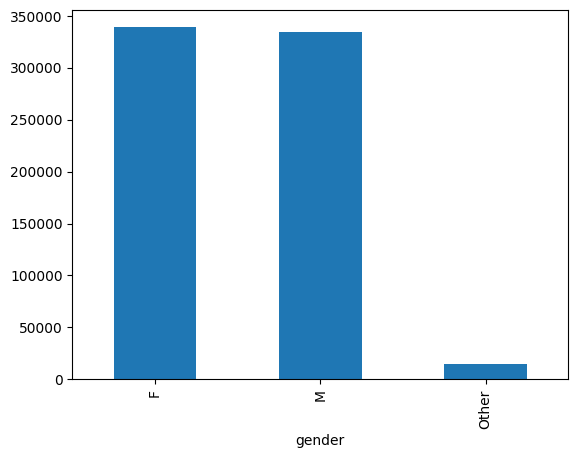

In [10]:
# Visualising gender distributions
df['gender'].value_counts().plot(kind='bar')

In [11]:
# Value counts for activity type
df['activity_type'].value_counts(bins=None)

activity_type
Yoga               69961
Weight Training    69661
HIIT               69376
Dancing            69193
Cycling            69187
Basketball         68536
Tennis             68532
Walking            68076
Swimming           68032
Running            67145
Name: count, dtype: int64

<Axes: xlabel='intensity_cat', ylabel='count'>

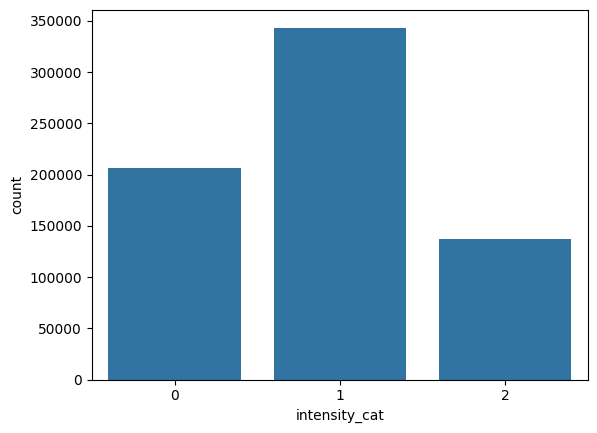

In [12]:
# Count plot showing how many records fall into each intensity category
sns.countplot(data=df, x='intensity_cat')

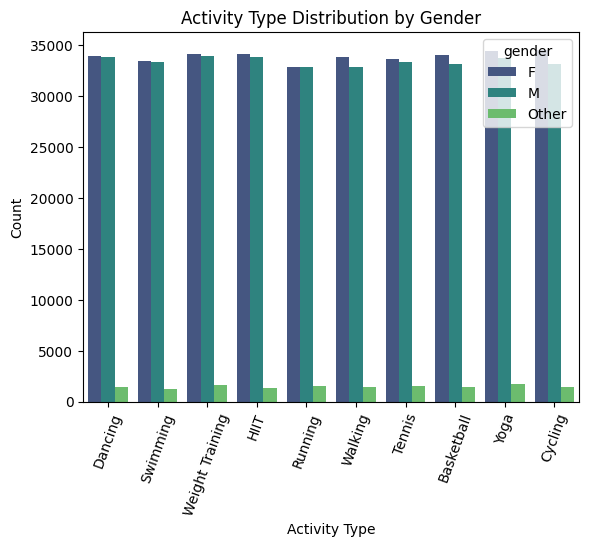

In [13]:
# Create a count plot to show the distribution of activity types, broken down by gender
sns.countplot(x='activity_type', hue='gender',data=df, palette='viridis')
plt.title('Activity Type Distribution by Gender')
plt.xlabel('Activity Type')
plt.ylabel('Count')
plt.xticks(rotation=70)
plt.show()

<Axes: xlabel='gender', ylabel='count'>

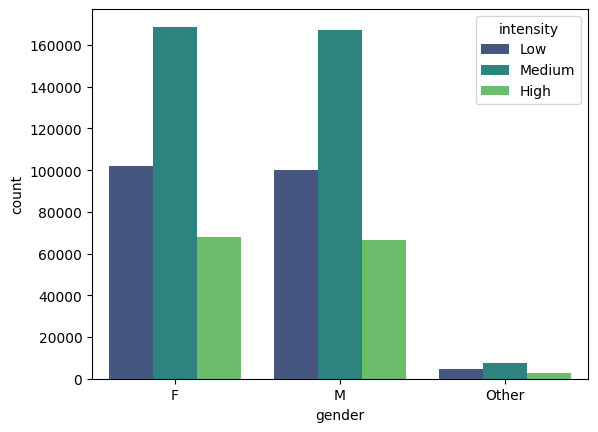

In [14]:
# Create a count plot to visualize the distribution of intensity levels across different genders
sns.countplot(x='gender', hue='intensity', data=df, palette='viridis')

In [15]:
# Show how intensity levels are distributed within each activity type.
pd.crosstab(df['activity_type'], df['intensity'], normalize='index')

intensity,High,Low,Medium
activity_type,,,
Basketball,0.197604,0.301360,0.501036
Cycling,0.200442,0.300591,0.498967
Dancing,0.199861,0.298744,0.501395
HIIT,0.198714,0.302915,0.498371
Running,0.200626,0.301541,0.497833
Swimming,0.199259,0.300403,0.500338
Tennis,0.198316,0.300808,0.500876
Walking,0.199865,0.301604,0.498531
Weight Training,0.202351,0.300096,0.497552


In [16]:
# Display DataFrame to review its current state and structure
df

,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,hours_sleep,stress_level,daily_steps,hydration_level,intensity_cat
0,56,F,165.3,53.7,Dancing,41,Low,3.3,6.6,3,7128,1.5,0
1,56,F,165.3,53.9,Swimming,28,Low,2.9,8.1,7,7925,1.8,0
2,56,F,165.3,54.2,Swimming,21,Medium,2.6,6.2,7,7557,2.7,1
3,56,F,165.3,54.4,Weight Training,99,Medium,10.7,7.2,8,11120,2.6,1
4,56,F,165.3,54.7,Swimming,100,Medium,12.7,7.1,1,5406,1.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
687694,38,F,165.7,112.9,Basketball,44,Medium,13.2,7.4,6,6911,1.9,1
687695,38,F,165.7,113.1,Basketball,25,Low,6.3,8.5,6,8932,2.6,0
687696,38,F,165.7,113.4,Yoga,97,Low,9.1,8.2,8,8864,1.8,0
687697,38,F,165.7,113.6,Basketball,108,Medium,32.6,8.5,4,7455,2.1,1


### Save data 

In [17]:
# Define the output path for saving the updated DataFrame
OUTPUT_PATH = Path("../data/latest.csv")
# Save the DataFrame to a CSV file at the specified path, without including the index
df.to_csv(OUTPUT_PATH, index=False)